# Библиотеки

In [124]:
import hashlib
import warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from datasets import load_dataset
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, classification_report, ConfusionMatrixDisplay

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup
from torch.optim import AdamW

from sklearn.neighbors import KNeighborsClassifier

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")

Device: cuda


# Загркзка данных

In [39]:
ds = load_dataset("Tobi-Bueck/customer-support-tickets")
df = ds["train"].to_pandas()

In [40]:
train_idx = np.loadtxt("train_idx.txt", dtype=np.int64)
val_idx   = np.loadtxt("val_idx.txt",   dtype=np.int64)
test_idx  = np.loadtxt("test_idx.txt",  dtype=np.int64)

splits = {
    "train": df.iloc[train_idx].reset_index(drop=True).copy(),
    "val":   df.iloc[val_idx].reset_index(drop=True).copy(),
    "test":  df.iloc[test_idx].reset_index(drop=True).copy(),
}

# Заполняем отсутствующий type как Unknown
for k in splits:
    splits[k]["type"] = splits[k]["type"].fillna("Unknown")

for k, d in splits.items():
    print(f"{k}: {len(d)} строк")

train: 49412 строк
val: 6176 строк
test: 6177 строк


# EDA

In [55]:
cols = ["subject", "body", "queue", "priority", "type", "language"]
miss_data = {}

for name, df in splits.items():
    miss_data[name] = {}
    for col in cols:
        if col in df.columns:
            miss_data[name][col] = df[col].isna().mean()

miss_df = pd.DataFrame(miss_data).T
miss_df

,subject,body,queue,priority,type,language
train,0.086376,0.00004,0.0,0.0,0.0,0.0
val,0.081768,0.00000,0.0,0.0,0.0,0.0
test,0.085155,0.00000,0.0,0.0,0.0,0.0


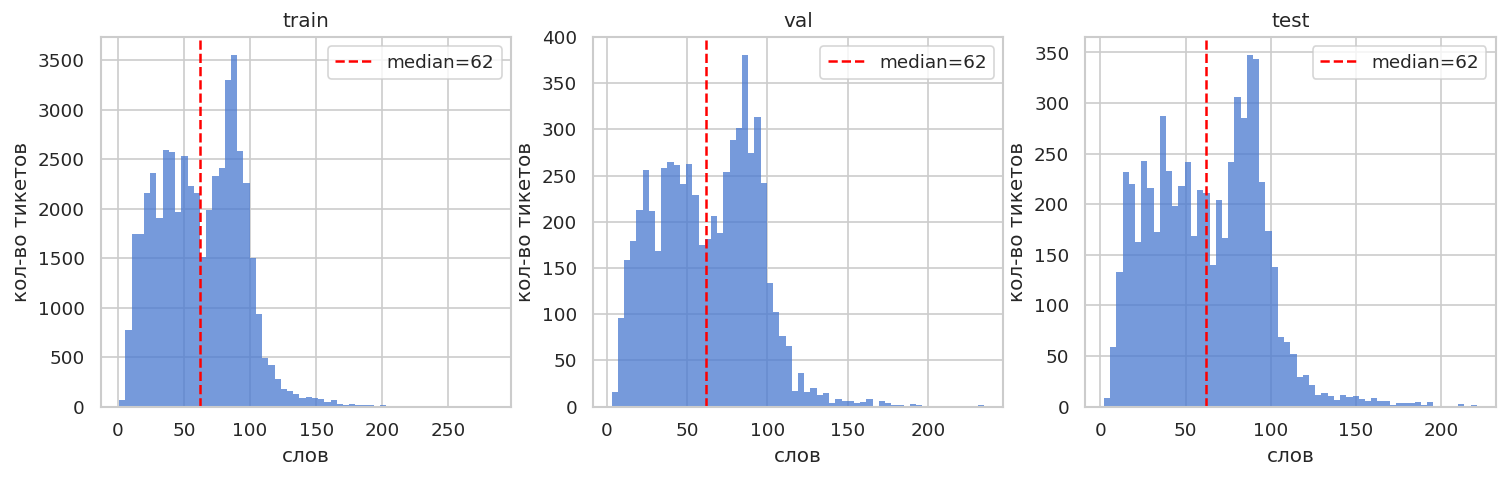

In [65]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (k, d) in zip(axes, splits.items()):
    txt = (d["subject"].fillna("") + "\n\n" + d["body"].fillna("")).astype(str)
    ws  = txt.str.split().map(len)
    ax.hist(ws, bins=60, edgecolor="none", alpha=0.75)
    ax.set_title(k)
    ax.set_xlabel("слов")
    ax.set_ylabel("кол-во тикетов")
    ax.axvline(ws.median(), color="red", ls="--", label=f"median={ws.median():.0f}")
    ax.legend()
plt.show()

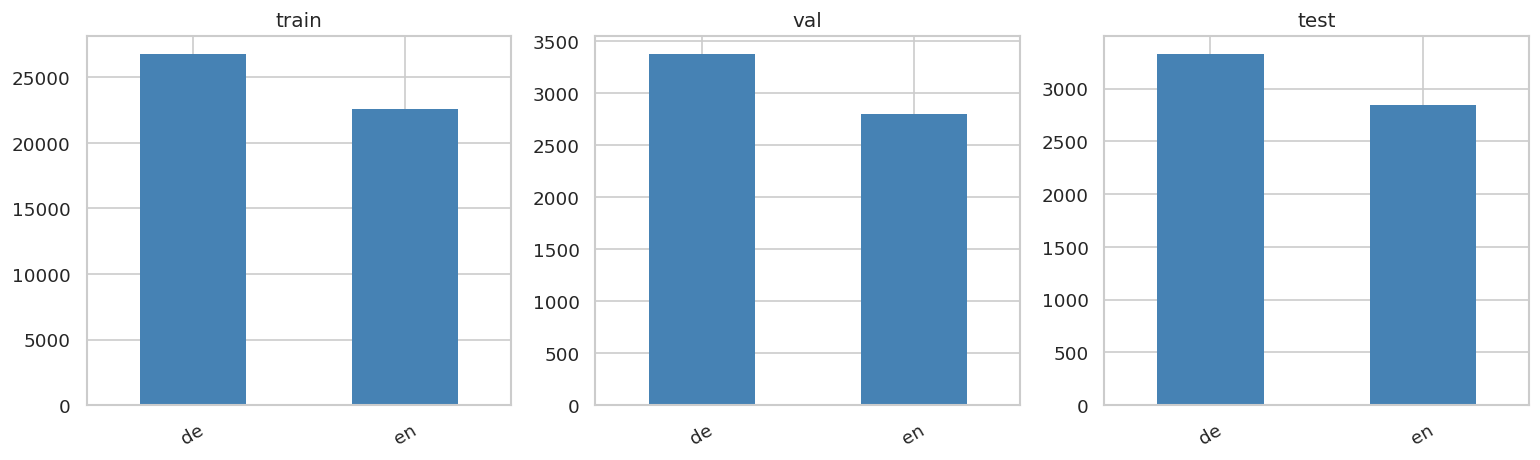

In [61]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

for ax, (k, d) in zip(axes, splits.items()):
    vc = d["language"].fillna("NA").value_counts().head(10)
    vc.plot.bar(ax=ax, color="steelblue", edgecolor="none")
    ax.set_title(k)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

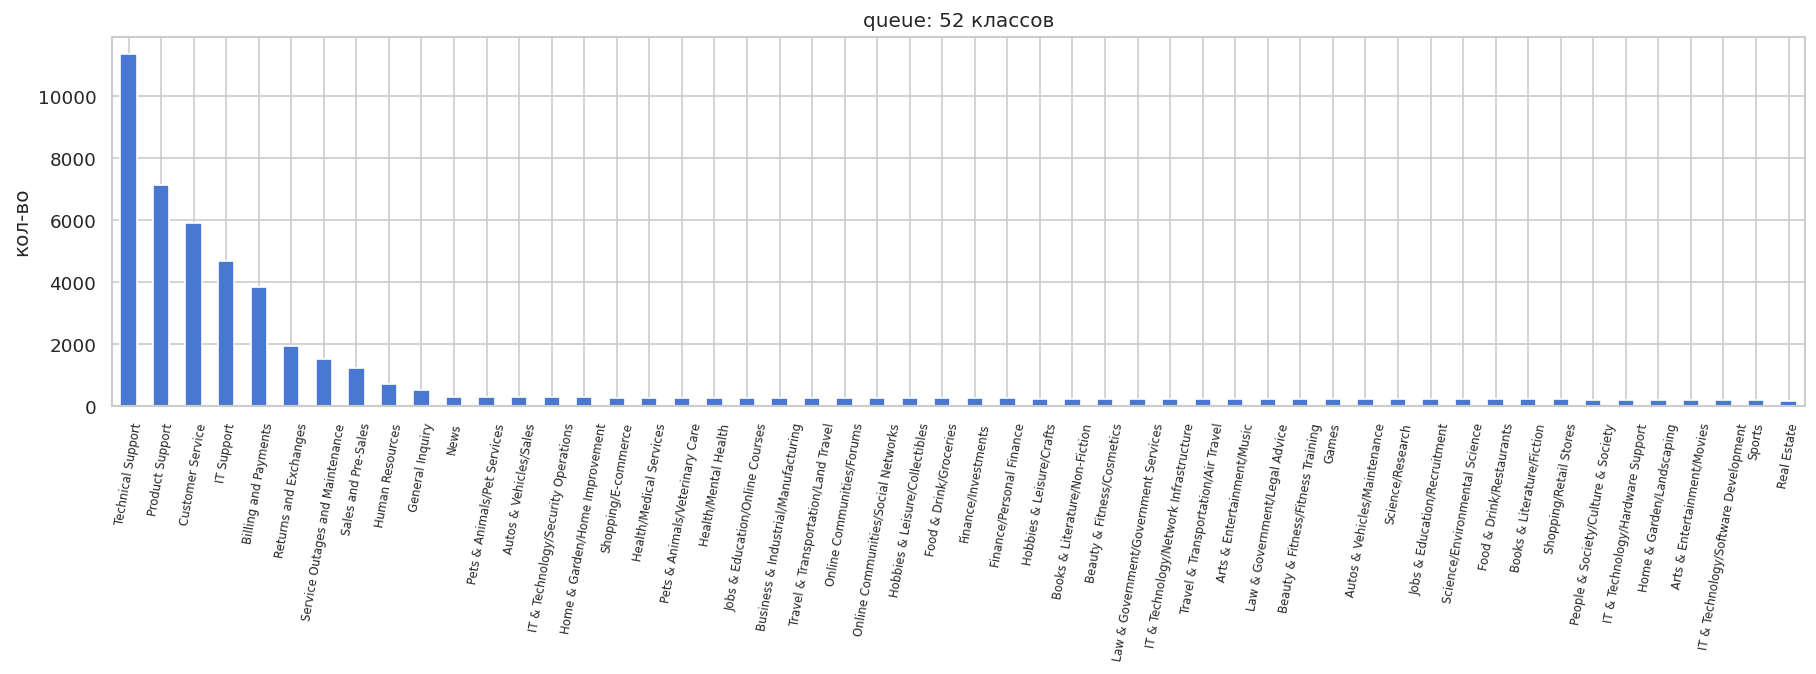

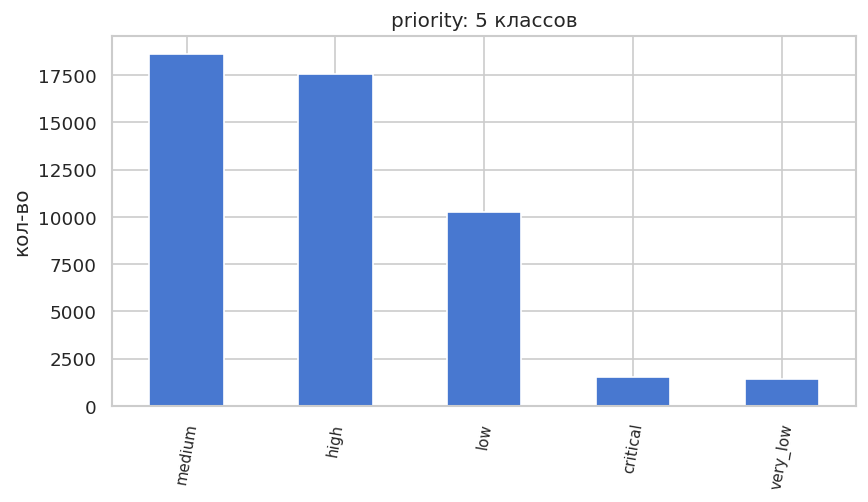

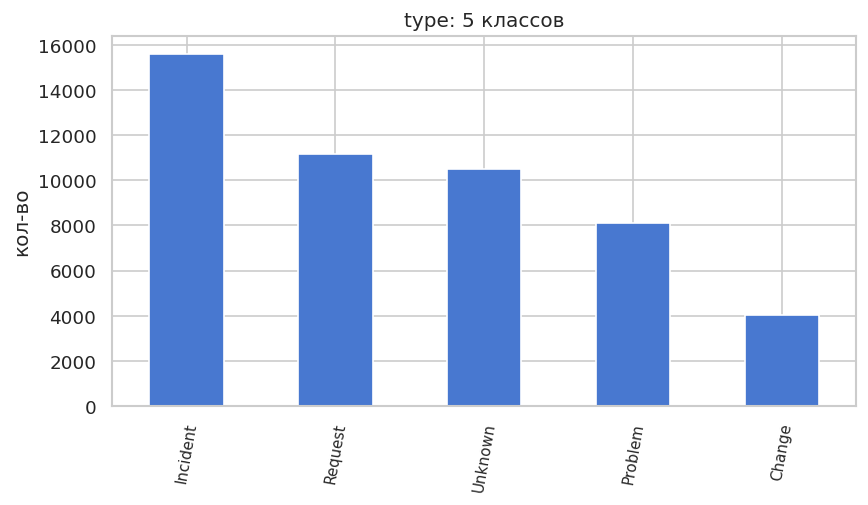

In [64]:
for target in ["queue", "priority", "type"]:
    vc_train = splits["train"][target].value_counts()
    n = len(vc_train)
    fig, ax = plt.subplots(figsize=(max(8, n * 0.35), 4))
    vc_train.plot.bar(ax=ax)
    ax.set_title(f"{target}: {n} классов")
    ax.set_xlabel("")
    ax.set_ylabel("кол-во")
    ax.tick_params(axis="x", rotation=80, labelsize=7 if n > 20 else 9)
    plt.show()

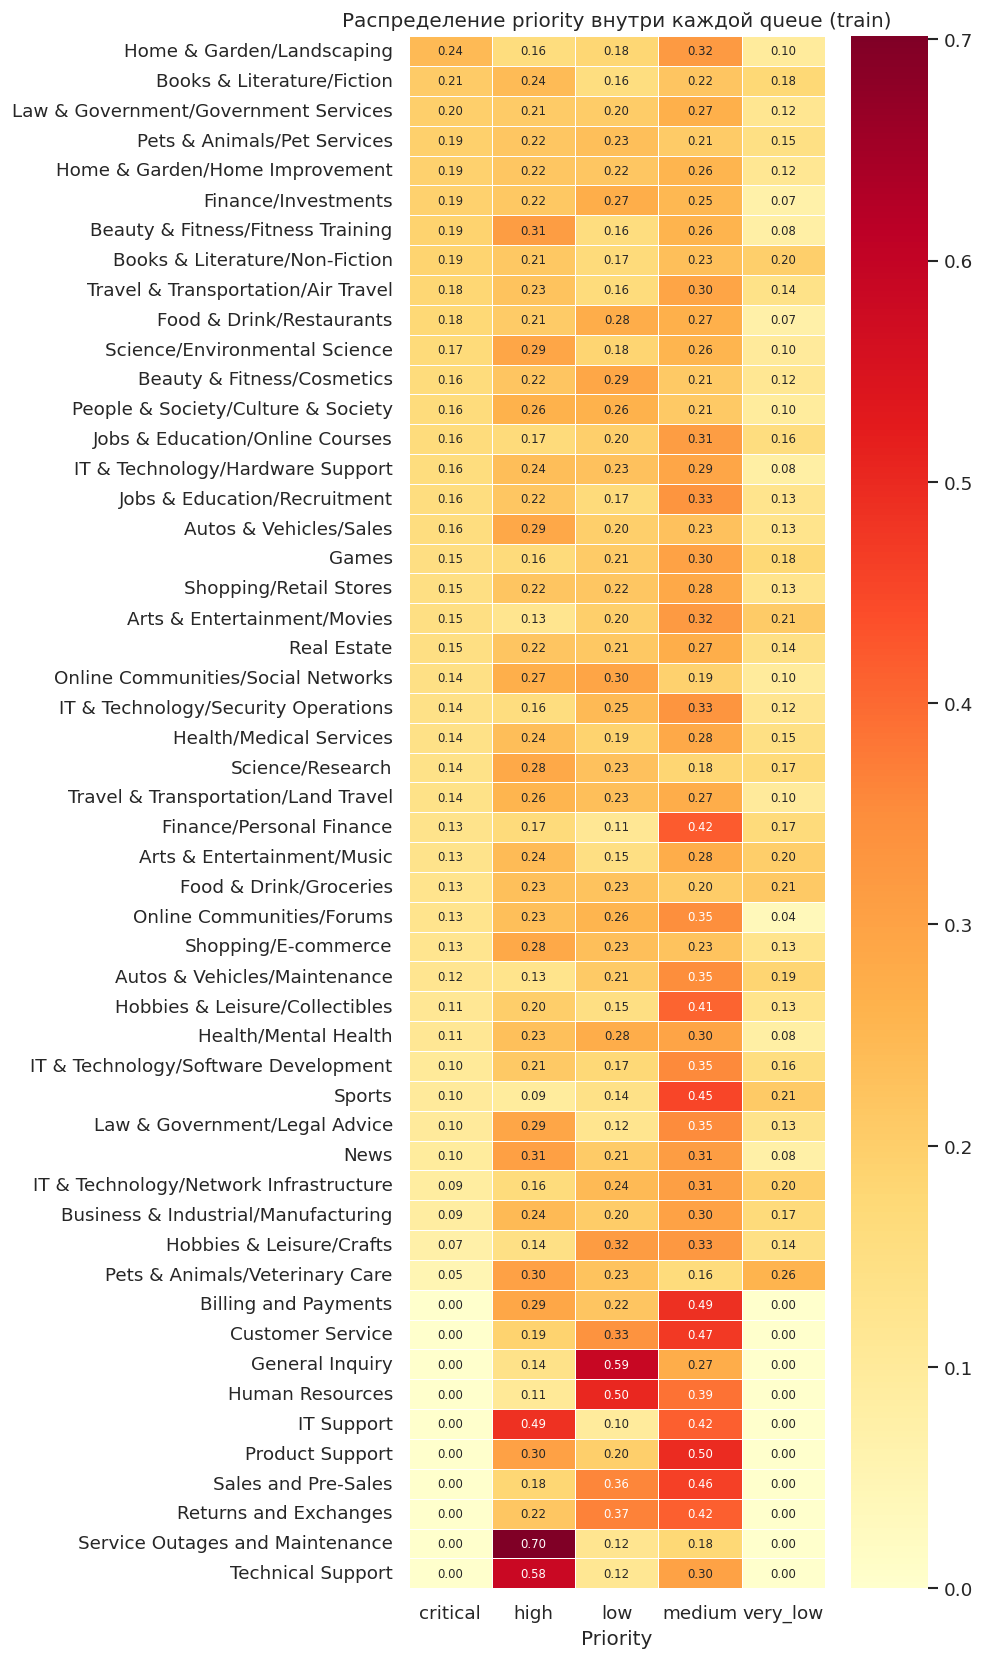

In [71]:
fig, ax = plt.subplots(figsize=(8, 14))
cross = pd.crosstab(splits["train"]["queue"],
                    splits["train"]["priority"],
                    normalize="index")
# сортируем по доле critical — самые "срочные" очереди сверху
cross_sorted = cross.sort_values("critical", ascending=False)
sns.heatmap(cross_sorted, annot=True, fmt=".2f",
            cmap="YlOrRd", linewidths=0.5, ax=ax,
            annot_kws={"size": 7})
ax.set_title("Распределение priority внутри каждой queue (train)", fontsize=12)
ax.set_xlabel("Priority")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

Ключевые наблюдения:
1. Billing and Payments: никогда critical/very_low — финансовые тикеты всегда medium-high приоритета
2. Beauty/Fitness, Arts/Entertainment: равномерное распределение - приоритет не зависит от тематики


Вывод: queue и priority коррелируют

<Axes: xlabel='type', ylabel='priority'>

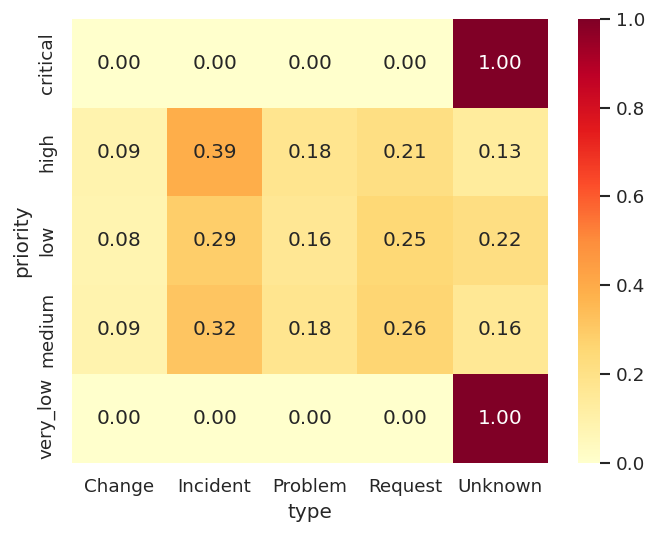

In [70]:
sns.heatmap(
    pd.crosstab(splits["train"]["priority"], splits["train"]["type"], normalize="index"),
    annot=True, fmt=".2f", cmap="YlOrRd"
)

Обнаружен важный прикол:
- critical priority: type=Unknown в 100% случаев
- very_low priority: type=Unknown в 100% случаев  
Это означает что тикеты с экстремальными приоритетами не имели разметки type

# Baseline: TF-IDF + LinearSVC

In [80]:
def make_text(d: pd.DataFrame) -> pd.Series:
    return (d["subject"].fillna("") + "\n\n" + d["body"].fillna("")).astype(str)

X_train_raw = make_text(splits["train"])
X_val_raw   = make_text(splits["val"])
X_test_raw  = make_text(splits["test"])

vec = TfidfVectorizer(max_features=200000, ngram_range=(1, 2), min_df=2, sublinear_tf=True)
X_tr = vec.fit_transform(X_train_raw)
X_va = vec.transform(X_val_raw)
X_te = vec.transform(X_test_raw)

In [81]:
def compute_score(results: dict) -> float:
    return 0.70 * results["queue_macro_f1"] + 0.15 * results["priority_acc"] + 0.15 * results["type_acc"]

baseline_results = {}
baseline_clfs = {}

for target in ["queue", "priority", "type"]:
    ytr = splits["train"][target].astype(str).values
    yte = splits["test"][target].astype(str).values

    clf = LinearSVC(max_iter=2000, C=0.5)
    clf.fit(X_tr, ytr)
    pred = clf.predict(X_te)
    baseline_clfs[target] = clf

    all_labels = sorted(list(set(ytr) | set(yte)))

    acc = float(accuracy_score(yte, pred))
    mf1 = float(f1_score(yte, pred, average="macro",
                         labels=all_labels,
                         zero_division=0))

    baseline_results[f"{target}_acc"] = acc
    baseline_results[f"{target}_macro_f1"] = mf1

    print(f"{target}: acc={acc:.4f}  macro_f1={mf1:.4f}")

score_baseline = compute_score(baseline_results)
print(f"BASELINE SCORE = {score_baseline:.4f}")

queue: acc=0.6751  macro_f1=0.8832
priority: acc=0.6979  macro_f1=0.7688
type: acc=0.8943  macro_f1=0.8946
BASELINE SCORE = 0.8571


In [13]:
ytr_q = splits["train"]["queue"].astype(str).values
yte_q = splits["test"]["queue"].astype(str).values
pred_q_baseline = baseline_clfs["queue"].predict(X_te)

cr = classification_report(yte_q, pred_q_baseline, output_dict=True, zero_division=0)
cr_df = pd.DataFrame(cr).T

cr_df = cr_df[~cr_df.index.isin(["accuracy", "macro avg", "weighted avg"])].sort_values("support", ascending=False)
print("Top-20 классов queue (baseline):")
cr_df.head(20)[["precision", "recall", "f1-score", "support"]].style.background_gradient(subset=["f1-score"], cmap="RdYlGn").format("{:.3f}", subset=["precision", "recall", "f1-score"]).format("{:.0f}", subset=["support"])

Top-20 классов queue (baseline):


,precision,recall,f1-score,support
Technical Support,0.549,0.775,0.643,1418
Product Support,0.562,0.540,0.551,937
Customer Service,0.532,0.548,0.540,766
Billing and Payments,0.850,0.767,0.806,532
IT Support,0.582,0.433,0.497,515
Returns and Exchanges,0.762,0.317,0.448,243
Service Outages and Maintenance,0.829,0.554,0.664,184
Sales and Pre-Sales,0.776,0.377,0.507,138
Human Resources,0.920,0.253,0.397,91
General Inquiry,0.905,0.302,0.452,63


Чётко виден разрыв между двумя группами классов:

- **Крупные общие очереди** (Technical Support, IT Support, Customer Service) —
  низкий recall (0.25–0.55): модель редко решается их предсказать, тк
  путает между собой

- **Мелкие специфичные очереди** (Science/Research, Hobbies/Crafts,
  IT Security Operations) — F1 ≥ 0.95: уникальный словарь однозначно идентифицирует класс

Это объясняет разрыв между accuracy=0.674 и macro_f1=0.883 —
хвостовые классы предсказываются идеально, но большинство тикетов
попадает именно в сложные крупные очереди

#Transformer (mDeBERTa-v3-base)

## Model 1

In [84]:
MODEL_NAME = "microsoft/mdeberta-v3-base"
MAX_LEN    = 256
BATCH_SIZE = 16
EPOCHS     = 4
LR         = 2e-5

# Энкодеры меток
label_encoders = {}
for target in ["queue", "priority", "type"]:
    le = LabelEncoder()
    le.fit(splits["train"][target].astype(str))
    label_encoders[target] = le
    print(f"{target}: {len(le.classes_)} классов")

queue: 52 классов
priority: 5 классов
type: 5 классов


In [85]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

class TicketDataset(Dataset):
    def __init__(self, df: pd.DataFrame, tokenizer, label_encoders: dict, max_len: int, is_test: bool = False):
        self.texts = (df["subject"].fillna("") + " [SEP] " + df["body"].fillna("")).astype(str).tolist()
        self.tokenizer = tokenizer
        self.label_encoders = label_encoders
        self.max_len = max_len
        self.is_test = is_test
        if not is_test:
            self.queue    = label_encoders["queue"].transform(df["queue"].astype(str))
            self.priority = label_encoders["priority"].transform(df["priority"].astype(str))
            self.type_    = label_encoders["type"].transform(df["type"].astype(str))

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            max_length=self.max_len,
            padding="max_length",
            truncation=True,
            return_tensors="pt",
        )
        item = {
            "input_ids":      enc["input_ids"].squeeze(),
            "attention_mask": enc["attention_mask"].squeeze(),
        }
        if "token_type_ids" in enc:
            item["token_type_ids"] = enc["token_type_ids"].squeeze()
        if not self.is_test:
            item["queue"]    = torch.tensor(self.queue[idx],    dtype=torch.long)
            item["priority"] = torch.tensor(self.priority[idx], dtype=torch.long)
            item["type"]     = torch.tensor(self.type_[idx],    dtype=torch.long)
        return item

In [86]:
class MultiTaskModel(nn.Module):
    def __init__(self, model_name: str, num_queue: int, num_priority: int, num_type: int, dropout: float = 0.1):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(model_name)
        hidden = self.encoder.config.hidden_size
        self.drop = nn.Dropout(dropout)
        self.head_queue    = nn.Linear(hidden, num_queue)
        self.head_priority = nn.Linear(hidden, num_priority)
        self.head_type     = nn.Linear(hidden, num_type)

    def forward(self, input_ids, attention_mask, token_type_ids=None):
        kwargs = {"input_ids": input_ids, "attention_mask": attention_mask}
        if token_type_ids is not None:
            kwargs["token_type_ids"] = token_type_ids
        out = self.encoder(**kwargs)
        h = self.drop(out.last_hidden_state[:, 0, :])
        return (
            self.head_queue(h),
            self.head_priority(h),
            self.head_type(h),
        )

In [87]:
train_ds = TicketDataset(splits["train"], tokenizer, label_encoders, MAX_LEN)
val_ds   = TicketDataset(splits["val"],   tokenizer, label_encoders, MAX_LEN)
test_ds  = TicketDataset(splits["test"],  tokenizer, label_encoders, MAX_LEN)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE*2, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE*2, shuffle=False, num_workers=2, pin_memory=True)

print(f"Train batches: {len(train_loader)}  |  Val: {len(val_loader)}  |  Test: {len(test_loader)}")


Train batches: 3089  |  Val: 193  |  Test: 194


In [89]:
n_queue    = len(label_encoders["queue"].classes_)
n_priority = len(label_encoders["priority"].classes_)
n_type     = len(label_encoders["type"].classes_)

model = MultiTaskModel(MODEL_NAME, n_queue, n_priority, n_type)
model = model.float().to(DEVICE)

optimizer = AdamW(model.parameters(), lr=LR, weight_decay=0.01)
total_steps = len(train_loader) * EPOCHS
scheduler   = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=total_steps // 10, num_training_steps=total_steps)

# по формуле скоринга
W_QUEUE    = 0.70
W_PRIORITY = 0.15
W_TYPE     = 0.15

criterion = nn.CrossEntropyLoss()

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

DebertaV2Model LOAD REPORT from: microsoft/mdeberta-v3-base
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
lm_predictions.lm_head.LayerNorm.bias      | UNEXPECTED |  | 
lm_predictions.lm_head.dense.bias          | UNEXPECTED |  | 
mask_predictions.classifier.bias           | UNEXPECTED |  | 
mask_predictions.classifier.weight         | UNEXPECTED |  | 
deberta.embeddings.word_embeddings._weight | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.weight    | UNEXPECTED |  | 
mask_predictions.dense.bias                | UNEXPECTED |  | 
lm_predictions.lm_head.dense.weight        | UNEXPECTED |  | 
lm_predictions.lm_head.bias                | UNEXPECTED |  | 
mask_predictions.LayerNorm.weight          | UNEXPECTED |  | 
mask_predictions.LayerNorm.bias            | UNEXPECTED |  | 
mask_predictions.dense.weight              | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/ar

In [90]:
def evaluate(model, loader, label_encoders, device):
    model.eval()
    all_preds = {"queue": [], "priority": [], "type": []}
    all_true  = {"queue": [], "priority": [], "type": []}

    with torch.no_grad():
        for batch in loader:
            ids  = batch["input_ids"].to(device)
            mask = batch["attention_mask"].to(device)
            tti  = batch.get("token_type_ids")
            if tti is not None: tti = tti.to(device)

            lq, lp, lt = model(ids, mask, tti)
            pq = lq.argmax(-1).cpu().numpy()
            pp = lp.argmax(-1).cpu().numpy()
            pt = lt.argmax(-1).cpu().numpy()

            all_preds["queue"].extend(pq)
            all_preds["priority"].extend(pp)
            all_preds["type"].extend(pt)

            all_true["queue"].extend(batch["queue"].numpy())
            all_true["priority"].extend(batch["priority"].numpy())
            all_true["type"].extend(batch["type"].numpy())

    res = {}
    for target in ["queue", "priority", "type"]:
        yt = np.array(all_true[target])
        yp = np.array(all_preds[target])
        res[f"{target}_acc"]      = float(accuracy_score(yt, yp))
        res[f"{target}_macro_f1"] = float(f1_score(yt, yp, average="macro", zero_division=0))
    return res, all_preds, all_true

In [93]:
train_losses = []
val_scores   = []
best_val_score = -1.0

for epoch in range(1, EPOCHS + 1):
    model.train()
    total_loss = 0.0

    for step, batch in enumerate(train_loader):
        ids  = batch["input_ids"].to(DEVICE)
        mask = batch["attention_mask"].to(DEVICE)
        tti  = batch.get("token_type_ids")
        if tti is not None: tti = tti.to(DEVICE)

        lq, lp, lt = model(ids, mask, tti)

        loss = (
            W_QUEUE    * criterion(lq, batch["queue"].to(DEVICE)) +
            W_PRIORITY * criterion(lp, batch["priority"].to(DEVICE)) +
            W_TYPE     * criterion(lt, batch["type"].to(DEVICE))
        )

        optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()

        if (step + 1) % 200 == 0:
            print(f"  E{epoch} step {step+1}/{len(train_loader)}  loss={loss.item():.4f}")

    avg_loss = total_loss / len(train_loader)
    train_losses.append(avg_loss)

    val_res, _, _ = evaluate(model, val_loader, label_encoders, DEVICE)
    val_score = compute_score(val_res)
    val_scores.append(val_score)

    print(f"\nEpoch {epoch}/{EPOCHS}  loss={avg_loss:.4f}  "
          f"val_queue_mF1={val_res['queue_macro_f1']:.4f}  "
          f"val_prio_acc={val_res['priority_acc']:.4f}  "
          f"val_type_acc={val_res['type_acc']:.4f}  "
          f"val_SCORE={val_score:.4f}")

    if val_score > best_val_score:
        best_val_score = val_score
        torch.save(model.state_dict(), 'model_1.pt')                              # сохраняю веса тк надоели велеты в колабе

  E1 step 200/3089  loss=2.6237
  E1 step 400/3089  loss=1.8358
  E1 step 600/3089  loss=1.8059
  E1 step 800/3089  loss=2.0953
  E1 step 1000/3089  loss=1.8159
  E1 step 1200/3089  loss=1.5550
  E1 step 1400/3089  loss=1.5172
  E1 step 1600/3089  loss=1.9717
  E1 step 1800/3089  loss=1.4644
  E1 step 2000/3089  loss=1.8221
  E1 step 2200/3089  loss=1.3301
  E1 step 2400/3089  loss=1.5927
  E1 step 2600/3089  loss=1.5878
  E1 step 2800/3089  loss=1.3384
  E1 step 3000/3089  loss=1.3902

Epoch 1/4  loss=1.7296  val_queue_mF1=0.6813  val_prio_acc=0.4388  val_type_acc=0.8279  val_SCORE=0.6669
  E2 step 200/3089  loss=1.2621
  E2 step 400/3089  loss=1.4324
  E2 step 600/3089  loss=1.2788
  E2 step 800/3089  loss=1.5575
  E2 step 1000/3089  loss=1.3423
  E2 step 1200/3089  loss=0.8589
  E2 step 1400/3089  loss=1.1517
  E2 step 1600/3089  loss=1.3600
  E2 step 1800/3089  loss=0.8410
  E2 step 2000/3089  loss=0.7804
  E2 step 2200/3089  loss=0.9821
  E2 step 2400/3089  loss=1.0404
  E2 step 2

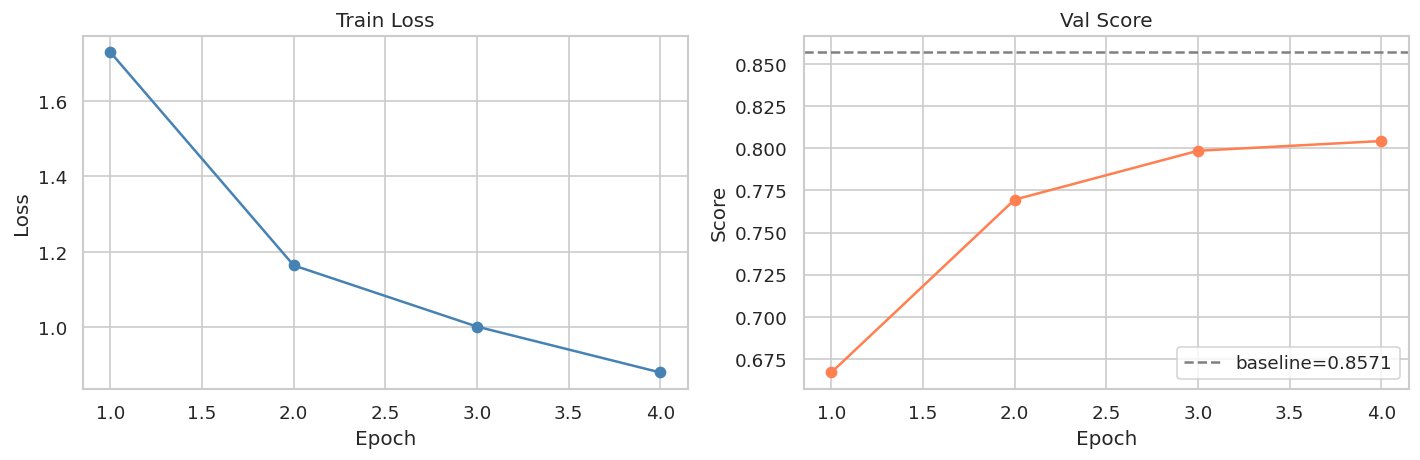

In [94]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(range(1, len(train_losses)+1), train_losses, marker="o", color="steelblue")
axes[0].set_title("Train Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")

axes[1].plot(range(1, len(val_scores)+1), val_scores, marker="o", color="coral")
axes[1].set_title("Val Score")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Score")
axes[1].axhline(score_baseline, ls="--", color="gray", label=f"baseline={score_baseline:.4f}")
axes[1].legend()

plt.tight_layout()
plt.show()

Val Score растёт (Loss убывает) и не выровнялся
к эпохе 4, что говорит о недообученности. Именно поэтому в следующих
версиях увеличиваем количество эпох до 6-8

In [98]:
model.load_state_dict(torch.load('model_1.pt', map_location=DEVICE))
test_res, test_preds_enc, test_true_enc = evaluate(model, test_loader, label_encoders, DEVICE)

score_transformer = compute_score(test_res)
score_1 = score_transformer

for target in ["queue", "priority", "type"]:
    print(f"{target:10s}  acc={test_res[f'{target}_acc']:.4f}  macro_f1={test_res[f'{target}_macro_f1']:.4f}")
print(f"\nMODEL 1 SCORE = {score_transformer:.4f}")
print(f"BASELINE SCORE = {score_baseline:.4f}")

queue       acc=0.6061  macro_f1=0.8579
priority    acc=0.5121  macro_f1=0.5179
type        acc=0.8446  macro_f1=0.8443

MODEL 1 SCORE = 0.8040
BASELINE SCORE = 0.8571


## Model 2

**Изменения**:

- Веса классов: вес - 1/√freq штрафует модель сильнее за ошибки на редких классах

- Раздельные LR: энкодер уже хорошо натренирован, ему нужен
осторожный шаг. Головы классификации инициализированы случайно -
им нужно учиться быстрее

- Label smoothing: предотвращает излишнюю уверенность модели,
лучше генерализируется на новых данных

- [NO_SUBJECT]: ~8.5% тикетов без темы письма. Вместо пустой строки
модель теперь явно "видит" что subject отсутствует

In [99]:
MODEL_NAME_2 = "microsoft/mdeberta-v3-base"
MAX_LEN_2    = 128
BATCH_SIZE_2 = 8
EPOCHS_2     = 6
LR_ENCODER    = 2e-5   # медленно для претренированного энкодера
LR_HEADS      = 1e-4   # быстро для новых голов классификации
LABEL_SMOOTH  = 0.1

def make_class_weights(series, device):
    vc = series.value_counts()
    weights = 1.0 / np.sqrt(vc.values.astype(float))
    weights = weights / weights.sum() * len(weights)   # нормируем
    # возвращаем в порядке LabelEncoder
    return torch.tensor(weights, dtype=torch.float32).to(device)

label_encoders_2 = {}
for target in ["queue", "priority", "type"]:
    from sklearn.preprocessing import LabelEncoder
    le = LabelEncoder()
    le.fit(splits["train"][target].astype(str))
    label_encoders_2[target] = le

queue_series = splits["train"]["queue"].astype(str)
queue_order  = pd.Series(label_encoders_2["queue"].classes_)
queue_vc     = queue_series.value_counts()
queue_w      = torch.tensor(
    [1.0 / np.sqrt(queue_vc.get(c, 1)) for c in queue_order],
    dtype=torch.float32
).to(DEVICE)
queue_w = queue_w / queue_w.mean()   # нормируем вокруг 1

prio_series = splits["train"]["priority"].astype(str)
prio_order  = pd.Series(label_encoders_2["priority"].classes_)
prio_vc     = prio_series.value_counts()
prio_w      = torch.tensor(
    [1.0 / np.sqrt(prio_vc.get(c, 1)) for c in prio_order],
    dtype=torch.float32
).to(DEVICE)
prio_w = prio_w / prio_w.mean()

print("Queue weights (топ-5 тяжёлых классов):")
ww = pd.Series(queue_w.cpu().numpy(), index=queue_order)
print(ww.sort_values(ascending=False).head(5).round(3).to_string())
print("\nPriority weights:")
print(pd.Series(prio_w.cpu().numpy(), index=prio_order).round(3).to_string())


Queue weights (топ-5 тяжёлых классов):
Real Estate                             1.316
Sports                                  1.305
IT & Technology/Software Development    1.254
Arts & Entertainment/Movies             1.250
Home & Garden/Landscaping               1.221

Priority weights:
critical    1.673
high        0.492
low         0.642
medium      0.477
very_low    1.716


In [100]:
class TicketDataset2(Dataset):
    def __init__(self, df, tokenizer, label_encoders, max_len):
        subj = df["subject"].fillna("").astype(str)
        subj = subj.apply(lambda s: "[NO_SUBJECT]" if s.strip() == "" else s)
        body = df["body"].fillna("").astype(str)
        self.texts = (subj + " [SEP] " + body).tolist()

        self.tokenizer = tokenizer
        self.max_len   = max_len
        self.queue    = label_encoders["queue"].transform(df["queue"].astype(str))
        self.priority = label_encoders["priority"].transform(df["priority"].astype(str))
        self.type_    = label_encoders["type"].transform(df["type"].astype(str))

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            max_length=self.max_len,
            padding="max_length",
            truncation=True,
            return_tensors="pt",
        )
        item = {
            "input_ids":      enc["input_ids"].squeeze(),
            "attention_mask": enc["attention_mask"].squeeze(),
            "queue":    torch.tensor(self.queue[idx],    dtype=torch.long),
            "priority": torch.tensor(self.priority[idx], dtype=torch.long),
            "type":     torch.tensor(self.type_[idx],    dtype=torch.long),
        }
        if "token_type_ids" in enc:
            item["token_type_ids"] = enc["token_type_ids"].squeeze()
        return item


train_ds_2 = TicketDataset2(splits["train"], tokenizer, label_encoders_2, MAX_LEN_2)
val_ds_2   = TicketDataset2(splits["val"],   tokenizer, label_encoders_2, MAX_LEN_2)
test_ds_2  = TicketDataset2(splits["test"],  tokenizer, label_encoders_2, MAX_LEN_2)

train_loader_2 = DataLoader(train_ds_2, batch_size=BATCH_SIZE_2, shuffle=True,  num_workers=2, pin_memory=True)
val_loader_2   = DataLoader(val_ds_2,   batch_size=BATCH_SIZE_2*2, shuffle=False, num_workers=2, pin_memory=True)
test_loader_2  = DataLoader(test_ds_2,  batch_size=BATCH_SIZE_2*2, shuffle=False, num_workers=2, pin_memory=True)
print(f"Train batches: {len(train_loader_2)}")

Train batches: 6177


In [101]:
n_queue_2    = len(label_encoders_2["queue"].classes_)
n_priority_2 = len(label_encoders_2["priority"].classes_)
n_type_2     = len(label_encoders_2["type"].classes_)

model_2 = MultiTaskModel(MODEL_NAME_2, n_queue_2, n_priority_2, n_type_2)
model_2 = model_2.float().to(DEVICE)

optimizer_2 = AdamW([
    {"params": model_2.encoder.parameters(), "lr": LR_ENCODER},
    {"params": model_2.head_queue.parameters(),    "lr": LR_HEADS},
    {"params": model_2.head_priority.parameters(), "lr": LR_HEADS},
    {"params": model_2.head_type.parameters(),     "lr": LR_HEADS},
    {"params": model_2.drop.parameters(),          "lr": LR_HEADS},
], weight_decay=0.01)

total_steps_2 = len(train_loader_2) * EPOCHS_2
scheduler_2   = get_linear_schedule_with_warmup(
    optimizer_2,
    num_warmup_steps=total_steps_2 // 10,
    num_training_steps=total_steps_2,
)

criterion_q  = nn.CrossEntropyLoss(weight=queue_w, label_smoothing=LABEL_SMOOTH)
criterion_p  = nn.CrossEntropyLoss(weight=prio_w,  label_smoothing=LABEL_SMOOTH)
criterion_t  = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTH)

W_QUEUE_2    = 0.70
W_PRIORITY_2 = 0.15
W_TYPE_2     = 0.15

print(f"Параметры модели: {sum(p.numel() for p in model_2.parameters()):,}")
print(f"LR encoder={LR_ENCODER}  LR heads={LR_HEADS}")


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

DebertaV2Model LOAD REPORT from: microsoft/mdeberta-v3-base
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
lm_predictions.lm_head.LayerNorm.bias      | UNEXPECTED |  | 
lm_predictions.lm_head.dense.bias          | UNEXPECTED |  | 
mask_predictions.classifier.bias           | UNEXPECTED |  | 
mask_predictions.classifier.weight         | UNEXPECTED |  | 
deberta.embeddings.word_embeddings._weight | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.weight    | UNEXPECTED |  | 
mask_predictions.dense.bias                | UNEXPECTED |  | 
lm_predictions.lm_head.dense.weight        | UNEXPECTED |  | 
lm_predictions.lm_head.bias                | UNEXPECTED |  | 
mask_predictions.LayerNorm.weight          | UNEXPECTED |  | 
mask_predictions.LayerNorm.bias            | UNEXPECTED |  | 
mask_predictions.dense.weight              | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/ar

Параметры модели: 278,266,430
LR encoder=2e-05  LR heads=0.0001


In [102]:
train_losses_2 = []
val_scores_2   = []
best_val_score_2  = -1.0

for epoch in range(1, EPOCHS_2 + 1):
    model_2.train()
    total_loss = 0.0

    for step, batch in enumerate(train_loader_2):
        ids  = batch["input_ids"].to(DEVICE)
        mask = batch["attention_mask"].to(DEVICE)
        tti  = batch.get("token_type_ids")
        if tti is not None: tti = tti.to(DEVICE)

        lq, lp, lt = model_2(ids, mask, tti)

        loss = (
            W_QUEUE_2    * criterion_q(lq, batch["queue"].to(DEVICE)) +
            W_PRIORITY_2 * criterion_p(lp, batch["priority"].to(DEVICE)) +
            W_TYPE_2     * criterion_t(lt, batch["type"].to(DEVICE))
        )

        optimizer_2.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(model_2.parameters(), 1.0)
        optimizer_2.step()
        scheduler_2.step()

        total_loss += loss.item()

        if (step + 1) % 200 == 0:
            print(f"  E{epoch} step {step+1}/{len(train_loader_2)}  loss={loss.item():.4f}")

    avg_loss = total_loss / len(train_loader_2)
    train_losses_2.append(avg_loss)

    val_res_2, _, _ = evaluate(model_2, val_loader_2, label_encoders_2, DEVICE)
    val_score_2 = compute_score(val_res_2)
    val_scores_2.append(val_score_2)

    print(f"\nEpoch {epoch}/{EPOCHS_2}  loss={avg_loss:.4f}  "
          f"val_queue_mF1={val_res_2['queue_macro_f1']:.4f}  "
          f"val_prio_acc={val_res_2['priority_acc']:.4f}  "
          f"val_type_acc={val_res_2['type_acc']:.4f}  "
          f"val_SCORE={val_score_2:.4f}")

    if val_score_2 > best_val_score_2:
        best_val_score_2 = val_score_2
        torch.save(model_2.state_dict(), "model_2.pt")

  E1 step 200/6177  loss=3.3341
  E1 step 400/6177  loss=3.7851
  E1 step 600/6177  loss=3.5177
  E1 step 800/6177  loss=3.3966
  E1 step 1000/6177  loss=3.0091
  E1 step 1200/6177  loss=3.0989
  E1 step 1400/6177  loss=3.4417
  E1 step 1600/6177  loss=3.0058
  E1 step 1800/6177  loss=3.1831
  E1 step 2000/6177  loss=3.0513
  E1 step 2200/6177  loss=3.2535
  E1 step 2400/6177  loss=2.9166
  E1 step 2600/6177  loss=3.4693
  E1 step 2800/6177  loss=2.9521
  E1 step 3000/6177  loss=2.7433
  E1 step 3200/6177  loss=2.9215
  E1 step 3400/6177  loss=2.3744
  E1 step 3600/6177  loss=3.3130
  E1 step 3800/6177  loss=2.3863
  E1 step 4000/6177  loss=2.2358
  E1 step 4200/6177  loss=2.3197
  E1 step 4400/6177  loss=2.2228
  E1 step 4600/6177  loss=2.4726
  E1 step 4800/6177  loss=2.5568
  E1 step 5000/6177  loss=2.5418
  E1 step 5200/6177  loss=2.3286
  E1 step 5400/6177  loss=2.8682
  E1 step 5600/6177  loss=1.6878
  E1 step 5800/6177  loss=2.8652
  E1 step 6000/6177  loss=2.2283

Epoch 1/6  lo

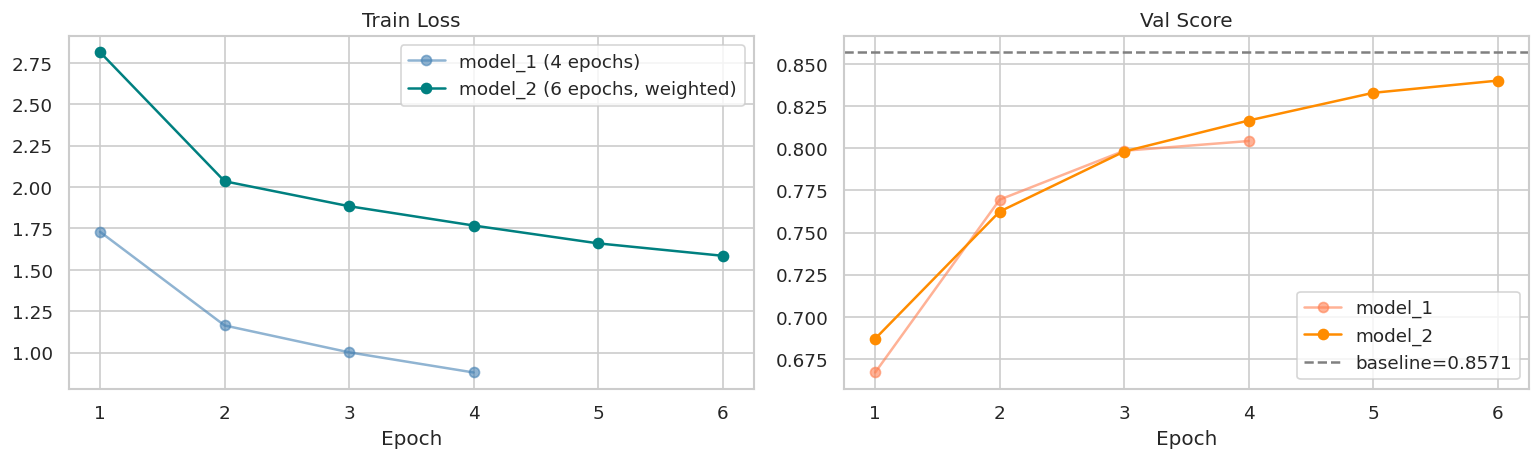

In [105]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(range(1, len(train_losses)+1),    train_losses,    marker="o", label="model_1 (4 epochs)", color="steelblue", alpha=0.6)
axes[0].plot(range(1, len(train_losses_2)+1), train_losses_2, marker="o", label="model_2 (6 epochs, weighted)", color="teal")
axes[0].set_title("Train Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(range(1, len(val_scores)+1),    val_scores,    marker="o", label="model_1", color="coral", alpha=0.6)
axes[1].plot(range(1, len(val_scores_2)+1), val_scores_2, marker="o", label="model_2", color="darkorange")
axes[1].axhline(score_baseline, ls="--", color="gray", label=f"baseline={score_baseline:.4f}")
axes[1].set_title("Val Score")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.show()


model_2 стартует с более высокого лосса - из-за взвешенного лосса
модель теперь сильнее штрафуется за ошибки на редких классах, что усложняет
начало обучения. Зато val score к эпохе 6 достигает 0.839 и продолжает расти -
обе кривые не выровнялись, что мотивирует перейти к model_3 с 8 эпохами

In [111]:
model_2.load_state_dict(torch.load("model_2.pt", map_location=DEVICE))
test_res_2, _, _ = evaluate(model_2, test_loader_2, label_encoders_2, DEVICE)
score_2 = compute_score(test_res_2)

for target in ["queue", "priority", "type"]:
    key = "macro_f1" if target == "queue" else "acc"
    delta = test_res_2[f"{target}_{key}"] - test_res[f"{target}_{key}"]
    sign  = "+" if delta >= 0 else ""
    print(f"{target}  {key}={test_res_2[f'{target}_{key}']:.4f}")

print(f"\nMODEL 2 SCORE = {score_2:.4f}")
print(f"MODEL 1 SCORE = {score_transformer:.4f}")
print(f"BASELINE = {score_baseline:.4f}")

queue  macro_f1=0.8954
priority  acc=0.5464
type  acc=0.8611

MODEL 2 SCORE = 0.8379
MODEL 1 SCORE = 0.8040
BASELINE = 0.8571


## Model 3

Изменения:

- Убрали label smoothing - в model 2 он конфликтовал с взвешенным лоссом:
модель получала противоречивые сигналы и нестабильно сходилась
(видно по скачкам лосса 0.8 → 3.2 в одной эпохе)

- Повысили вес priority - priority_acc в model 2 застрял на 0.54–0.56,
хотя val кривая ещё росла
- Увеличила кол-во эпох до 12 (придётся подождать😑)

In [118]:
EPOCHS_3     = 12
LR_ENCODER_3 = 2e-5
LR_HEADS_3   = 1e-4
W_QUEUE_3    = 0.63
W_PRIORITY_3 = 0.22
W_TYPE_3     = 0.15

criterion_q_3 = nn.CrossEntropyLoss(weight=queue_w)
criterion_p_3 = nn.CrossEntropyLoss(weight=prio_w)
criterion_t_3 = nn.CrossEntropyLoss()

model_3 = MultiTaskModel(MODEL_NAME_2, n_queue_2, n_priority_2, n_type_2)
model_3 = model_3.float().to(DEVICE)

optimizer_3 = AdamW([
    {"params": model_3.encoder.parameters(),       "lr": LR_ENCODER_3},
    {"params": model_3.head_queue.parameters(),    "lr": LR_HEADS_3},
    {"params": model_3.head_priority.parameters(), "lr": LR_HEADS_3},
    {"params": model_3.head_type.parameters(),     "lr": LR_HEADS_3},
    {"params": model_3.drop.parameters(),          "lr": LR_HEADS_3},
], weight_decay=0.01)

total_steps_3 = len(train_loader_2) * EPOCHS_3
scheduler_3   = get_linear_schedule_with_warmup(
    optimizer_3,
    num_warmup_steps=total_steps_3 // 10,
    num_training_steps=total_steps_3,
)

train_losses_3 = []
val_scores_3   = []
best_val_score_3  = -1.0

for epoch in range(1, EPOCHS_3 + 1):
    model_3.train()
    total_loss = 0.0

    for step, batch in enumerate(train_loader_2):
        ids  = batch["input_ids"].to(DEVICE)
        mask = batch["attention_mask"].to(DEVICE)
        tti  = batch.get("token_type_ids")
        if tti is not None: tti = tti.to(DEVICE)

        lq, lp, lt = model_3(ids, mask, tti)

        loss = (
            W_QUEUE_3    * criterion_q_3(lq, batch["queue"].to(DEVICE)) +
            W_PRIORITY_3 * criterion_p_3(lp, batch["priority"].to(DEVICE)) +
            W_TYPE_3     * criterion_t_3(lt, batch["type"].to(DEVICE))
        )

        optimizer_3.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(model_3.parameters(), 1.0)
        optimizer_3.step()
        scheduler_3.step()

        total_loss += loss.item()

        if (step + 1) % 500 == 0:
            print(f"  E{epoch} step {step+1}/{len(train_loader_2)}  loss={loss.item():.4f}")

    avg_loss = total_loss / len(train_loader_2)
    train_losses_3.append(avg_loss)

    val_res_3, _, _ = evaluate(model_3, val_loader_2, label_encoders_2, DEVICE)
    val_score_3 = compute_score(val_res_3)
    val_scores_3.append(val_score_3)

    print(f"\nEpoch {epoch}/{EPOCHS_3}  loss={avg_loss:.4f}  "
          f"val_queue_mF1={val_res_3['queue_macro_f1']:.4f}  "
          f"val_prio_acc={val_res_3['priority_acc']:.4f}  "
          f"val_type_acc={val_res_3['type_acc']:.4f}  "
          f"val_SCORE={val_score_3:.4f}")

    if val_score_3 > best_val_score_3:
        best_val_score_3 = val_score_3
        torch.save(model_3.state_dict(), 'model_3.pt')

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

DebertaV2Model LOAD REPORT from: microsoft/mdeberta-v3-base
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
lm_predictions.lm_head.LayerNorm.bias      | UNEXPECTED |  | 
lm_predictions.lm_head.dense.bias          | UNEXPECTED |  | 
mask_predictions.classifier.bias           | UNEXPECTED |  | 
mask_predictions.classifier.weight         | UNEXPECTED |  | 
deberta.embeddings.word_embeddings._weight | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.weight    | UNEXPECTED |  | 
mask_predictions.dense.bias                | UNEXPECTED |  | 
lm_predictions.lm_head.dense.weight        | UNEXPECTED |  | 
lm_predictions.lm_head.bias                | UNEXPECTED |  | 
mask_predictions.LayerNorm.weight          | UNEXPECTED |  | 
mask_predictions.LayerNorm.bias            | UNEXPECTED |  | 
mask_predictions.dense.weight              | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/ar

  E1 step 500/6177  loss=3.3466
  E1 step 1000/6177  loss=2.4953
  E1 step 1500/6177  loss=1.5550
  E1 step 2000/6177  loss=1.9409
  E1 step 2500/6177  loss=2.2460
  E1 step 3000/6177  loss=2.4772
  E1 step 3500/6177  loss=2.1482
  E1 step 4000/6177  loss=1.9215
  E1 step 4500/6177  loss=1.3815
  E1 step 5000/6177  loss=1.3892
  E1 step 5500/6177  loss=1.9979
  E1 step 6000/6177  loss=1.1851

Epoch 1/12  loss=2.1560  val_queue_mF1=0.5847  val_prio_acc=0.4417  val_type_acc=0.8175  val_SCORE=0.5982
  E2 step 500/6177  loss=1.3603
  E2 step 1000/6177  loss=1.6716
  E2 step 1500/6177  loss=1.1798
  E2 step 2000/6177  loss=0.8738
  E2 step 2500/6177  loss=0.5654
  E2 step 3000/6177  loss=1.7048
  E2 step 3500/6177  loss=0.5770
  E2 step 4000/6177  loss=1.2671
  E2 step 4500/6177  loss=0.8210
  E2 step 5000/6177  loss=1.1637
  E2 step 5500/6177  loss=1.5576
  E2 step 6000/6177  loss=1.2184

Epoch 2/12  loss=1.0708  val_queue_mF1=0.7898  val_prio_acc=0.4733  val_type_acc=0.8389  val_SCORE=0.7

In [121]:
model_3.load_state_dict(torch.load('model_3.pt', map_location=DEVICE))
test_res_3, _, _ = evaluate(model_3, test_loader_2, label_encoders_2, DEVICE)
score_3 = compute_score(test_res_3)

headers = {"queue": "macro_f1", "priority": "acc", "type": "acc"}
for target, key in headers.items():
    val   = test_res_3[f"{target}_{key}"]
    delta = val - test_res_2[f"{target}_{key}"]
    sign  = "+" if delta >= 0 else ""
    print(f"{target:10s}  {key}={val:.4f}")

queue       macro_f1=0.9237
priority    acc=0.7408
type        acc=0.8961



Model 3 SCORE = 0.8921
2Model 2 SCORE = 0.8379
BASELINE = 0.8571


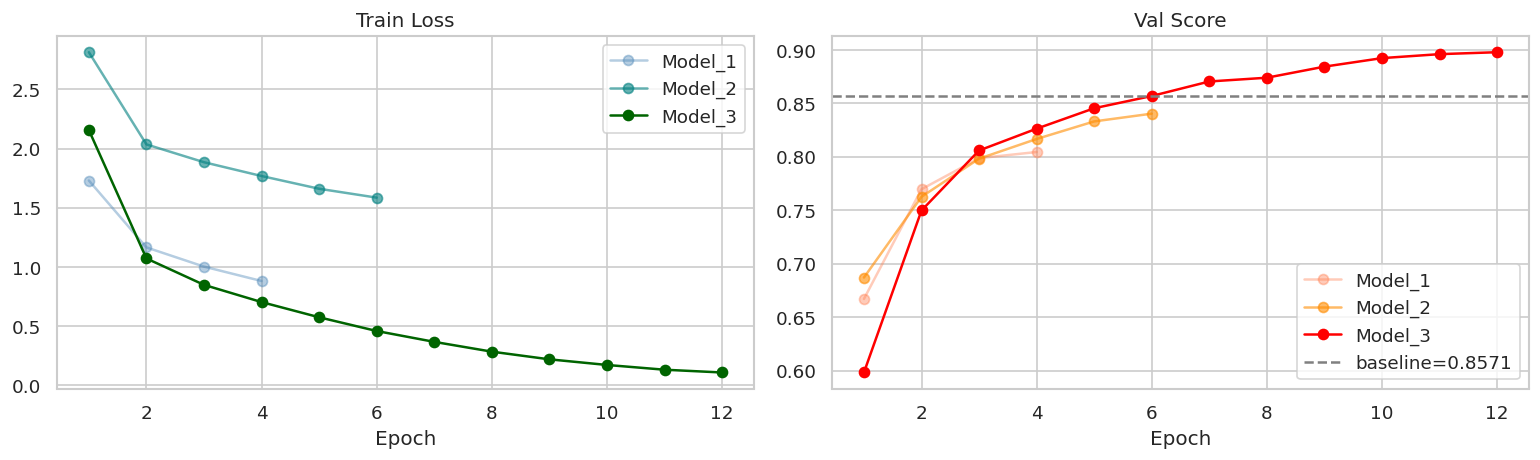

In [123]:
print(f"\nModel 3 SCORE = {score_3:.4f}")
print(f"2Model 2 SCORE = {score_2:.4f}")
print(f"BASELINE = {score_baseline:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(range(1, len(train_losses)+1),    train_losses,    marker="o", label="Model_1", color="steelblue", alpha=0.4)
axes[0].plot(range(1, len(train_losses_2)+1), train_losses_2, marker="o", label="Model_2", color="teal",      alpha=0.6)
axes[0].plot(range(1, len(train_losses_3)+1), train_losses_3, marker="o", label="Model_3", color="darkgreen")
axes[0].set_title("Train Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(range(1, len(val_scores)+1),    val_scores,    marker="o", label="Model_1", color="coral",      alpha=0.4)
axes[1].plot(range(1, len(val_scores_2)+1), val_scores_2, marker="o", label="Model_2", color="darkorange", alpha=0.6)
axes[1].plot(range(1, len(val_scores_3)+1), val_scores_3, marker="o", label="Model_3", color="red")
axes[1].axhline(score_baseline, ls="--", color="gray", label=f"baseline={score_baseline:.4f}")
axes[1].set_title("Val Score")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.show()

## + KNN (Best)

Вместо голов классификации используем KNN - для нового тикета
находим K ближайших соседей в трейне и предсказываем класс голосованием

In [129]:
def get_embeddings(model, loader, device):
    model.eval()
    all_embs = []
    all_queue, all_prio, all_type = [], [], []
    with torch.no_grad():
        for batch in loader:
            ids  = batch["input_ids"].to(device)
            mask = batch["attention_mask"].to(device)
            tti  = batch.get("token_type_ids")
            if tti is not None: tti = tti.to(device)
            out  = model_3.encoder(input_ids=ids, attention_mask=mask,
                                    token_type_ids=tti)
            cls  = out.last_hidden_state[:, 0, :].cpu().numpy()
            all_embs.append(cls)
            all_queue.extend(batch["queue"].numpy())
            all_prio.extend(batch["priority"].numpy())
            all_type.extend(batch["type"].numpy())
    return (np.vstack(all_embs),
            np.array(all_queue),
            np.array(all_prio),
            np.array(all_type))

X_train_emb, y_train_q, y_train_p, y_train_t = get_embeddings(model_3, train_loader_2, DEVICE)
print(f"Train: {X_train_emb.shape}")

X_test_emb, y_test_q, y_test_p, y_test_t = get_embeddings(model_3, test_loader_2, DEVICE)
print(f"Test:  {X_test_emb.shape}")

Train: (49412, 768)
Test:  (6177, 768)


In [131]:
knn_results = {}

for target, y_tr, y_te in [
    ("queue",    y_train_q, y_test_q),
    ("priority", y_train_p, y_test_p),
    ("type",     y_train_t, y_test_t),
]:
    print(f"\n[{target}] подбираем K...")
    best_k, best_f1 = 1, 0.0

    for k in [1, 3, 5, 10, 15]:
        knn = KNeighborsClassifier(n_neighbors=k, metric="cosine", n_jobs=-1)
        knn.fit(X_train_emb, y_tr)
        pred = knn.predict(X_test_emb)
        mf1  = f1_score(y_te, pred, average="macro", zero_division=0)
        acc  = accuracy_score(y_te, pred)
        print(f"  K={k:2d}  macro_f1={mf1:.4f}  acc={acc:.4f}")
        if mf1 > best_f1:
            best_f1, best_k = mf1, k

    # финальная модель с лучшим K
    knn_final = KNeighborsClassifier(n_neighbors=best_k, metric="cosine", n_jobs=-1)
    knn_final.fit(X_train_emb, y_tr)
    pred_final = knn_final.predict(X_test_emb)
    knn_results[f"{target}_acc"]      = float(accuracy_score(y_te, pred_final))
    knn_results[f"{target}_macro_f1"] = float(f1_score(y_te, pred_final, average="macro", zero_division=0))
    print(f"  → Лучший K={best_k}")

score_knn = compute_score(knn_results)
print(f"\n=== KNN RESULTS ===")
print(f"queue    macro_f1={knn_results['queue_macro_f1']:.4f}")
print(f"priority acc={knn_results['priority_acc']:.4f}")
print(f"type     acc={knn_results['type_acc']:.4f}")
print(f"\nKNN SCORE  = {score_knn:.4f}")
print(f"MODEL 3 SCORE   = {score_3:.4f}")
print(f"BASELINE   = {score_baseline:.4f}")


[queue] подбираем K...
  K= 1  macro_f1=0.9286  acc=0.7653
  K= 3  macro_f1=0.9268  acc=0.7531
  K= 5  macro_f1=0.9262  acc=0.7499
  K=10  macro_f1=0.9246  acc=0.7475
  K=15  macro_f1=0.9247  acc=0.7487
  → Лучший K=1

[priority] подбираем K...
  K= 1  macro_f1=0.8435  acc=0.7759
  K= 3  macro_f1=0.8345  acc=0.7649
  K= 5  macro_f1=0.8273  acc=0.7518
  K=10  macro_f1=0.8228  acc=0.7460
  K=15  macro_f1=0.8211  acc=0.7431
  → Лучший K=1

[type] подбираем K...
  K= 1  macro_f1=0.9139  acc=0.9090
  K= 3  macro_f1=0.9127  acc=0.9089
  K= 5  macro_f1=0.9079  acc=0.9045
  K=10  macro_f1=0.8994  acc=0.8972
  K=15  macro_f1=0.8999  acc=0.8972
  → Лучший K=1

=== KNN RESULTS ===
queue    macro_f1=0.9286
priority acc=0.7759
type     acc=0.9090

KNN SCORE  = 0.9028
MODEL 3 SCORE   = 0.8921
BASELINE   = 0.8571


# Confidence / Selective Prediction анализ

В реальной системе маршрутизации тикетов не обязательно автоматизировать все
предсказания - можно отправлять неуверенные случаи на ручную проверку

Идея: сортируем тестовые примеры по уверенности модели, берём топ-X% самых уверенных и считаем Macro-F1(queue) только на них

Не рассматриваю модель с KNN, тк у меня KNN=1, след. это значит уверенность всегда либо 0 либо 1. Selective prediction с K=1 бессмысленна ведь нельзя отсортировать по уверенности если все значения одинаковые. Поэтому сравниваю бэздайн и 3 модель

In [133]:
# Собираем softmax-вероятности Model 3 на тест-сете
model_3.eval()
all_probs_q = []
all_true_q  = []

with torch.no_grad():
    for batch in test_loader_2:
        ids  = batch["input_ids"].to(DEVICE)
        mask = batch["attention_mask"].to(DEVICE)
        tti  = batch.get("token_type_ids")
        if tti is not None: tti = tti.to(DEVICE)

        lq, _, _ = model_3(ids, mask, tti)
        probs = torch.softmax(lq, dim=-1).cpu().numpy()
        all_probs_q.append(probs)
        all_true_q.extend(batch["queue"].numpy())

probs_q = np.vstack(all_probs_q)
conf_q  = probs_q.max(axis=1)    # уверенность = максимальная вероятность
preds_q = probs_q.argmax(axis=1)
true_q  = np.array(all_true_q)

print(f"Средняя уверенность Model 3: {conf_q.mean():.3f}  |  медиана: {np.median(conf_q):.3f}")

Средняя уверенность Model 3: 0.922  |  медиана: 0.998


In [135]:
df_scores_baseline = baseline_clfs["queue"].decision_function(X_te)
conf_baseline  = np.abs(df_scores_baseline).max(axis=1)
conf_baseline  = (conf_baseline - conf_baseline.min()) / (conf_baseline.max() - conf_baseline.min())
preds_baseline = baseline_clfs["queue"].predict(X_te)
true_baseline  = splits["test"]["queue"].astype(str).values

In [142]:
def selective_f1_curve(conf, preds, true, thresholds=None):
    if thresholds is None:
        thresholds = np.arange(0.1, 1.01, 0.05)
    sorted_idx = np.argsort(-conf)
    coverages, f1s = [], []
    for tau in thresholds:
        k   = max(1, int(np.ceil(tau * len(conf))))
        sel = sorted_idx[:k]
        mf1 = f1_score(true[sel], preds[sel], average="macro", zero_division=0)
        coverages.append(tau)
        f1s.append(mf1)
    return np.array(coverages), np.array(f1s)

thresh = np.arange(0.10, 1.01, 0.05)

cov_t, f1_t = selective_f1_curve(conf_q, preds_q, true_q, thresholds=thresh)

le_queue     = label_encoders_2["queue"]
preds_bl_enc = le_queue.transform(preds_baseline)
true_bl_enc  = le_queue.transform(true_baseline)
cov_b, f1_b  = selective_f1_curve(conf_baseline, preds_bl_enc, true_bl_enc, thresholds=thresh)

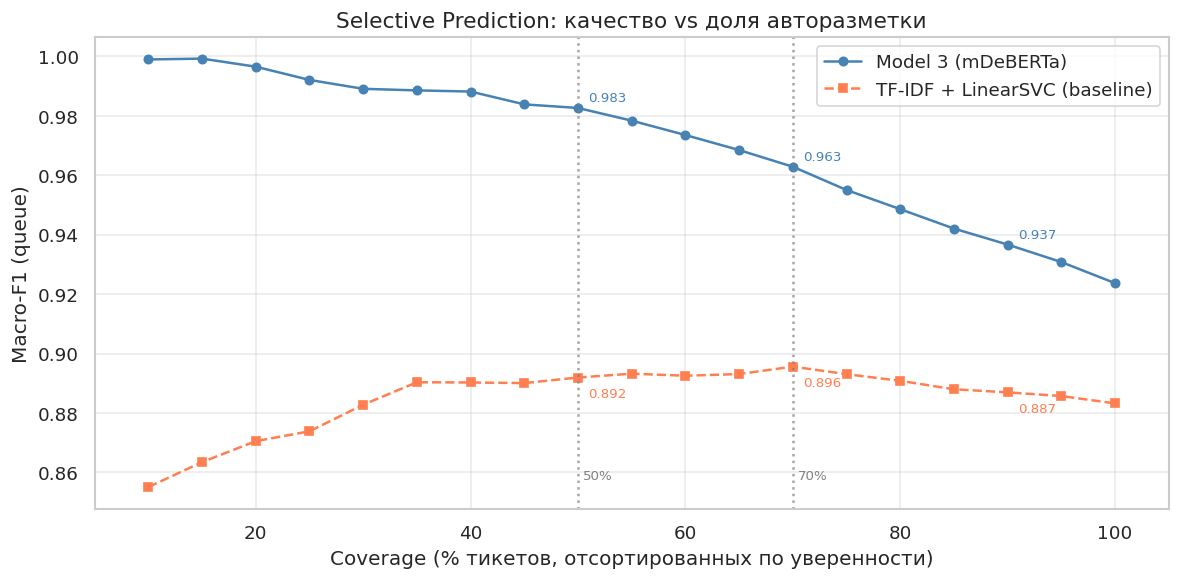

In [143]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(cov_t * 100, f1_t, marker="o", ms=5, label="Model 3 (mDeBERTa)", color="steelblue")
ax.plot(cov_b * 100, f1_b, marker="s", ms=5, label="TF-IDF + LinearSVC (baseline)",
        color="coral", ls="--")

for tau in [0.50, 0.70, 0.90]:
    idx   = np.argmin(np.abs(cov_t - tau))
    idx_b = np.argmin(np.abs(cov_b - tau))
    ax.annotate(f"{f1_t[idx]:.3f}",   (cov_t[idx]*100,   f1_t[idx]),
                textcoords="offset points", xytext=(6,  4), fontsize=8, color="steelblue")
    ax.annotate(f"{f1_b[idx_b]:.3f}", (cov_b[idx_b]*100, f1_b[idx_b]),
                textcoords="offset points", xytext=(6, -12), fontsize=8, color="coral")

for x, lbl in [(70, "70%"), (50, "50%")]:
    ax.axvline(x, color="gray", ls=":", alpha=0.7)
    ax.text(x + 0.5, ax.get_ylim()[0] + 0.01, lbl, fontsize=8, color="gray")

ax.set_xlabel("Coverage (% тикетов, отсортированных по уверенности)", fontsize=12)
ax.set_ylabel("Macro-F1 (queue)", fontsize=12)
ax.set_title("Selective Prediction: качество vs доля авторазметки", fontsize=13)
ax.set_xlim(5, 105)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

1. Model 3 значительно превосходит baseline на всём диапазоне coverage

2. Кривая Model 3 монотонно убывает - чем меньше тикетов берём, тем они
легче, след качество выше.
3. Baseline почти плоский, его
уверенность плохо коррелирует с правильностью предсказания

In [152]:
# Таблица по ключевым порогам
key_cov = [1.0, 0.9, 0.8, 0.7, 0.6, 0.5]
rows = []
for tau in key_cov:
    idx_t = np.argmin(np.abs(cov_t - tau))
    idx_b = np.argmin(np.abs(cov_b - tau))
    rows.append({
        "coverage":       f"{int(tau*100)}%",
        "manual_review":  f"{int((1-tau)*100)}%",
        "Model3_mF1":     round(f1_t[idx_t], 4),
        "baseline_mF1":   round(f1_b[idx_b], 4),
    })

pd.DataFrame(rows).style.background_gradient(subset=["Model3_mF1", "baseline_mF1"])

,coverage,manual_review,Model3_mF1,baseline_mF1
0,100%,0%,0.923700,0.883200
1,90%,9%,0.936600,0.886900
2,80%,19%,0.948600,0.890800
3,70%,30%,0.962800,0.895600
4,60%,40%,0.973500,0.892500
5,50%,50%,0.982600,0.891900


Разрыв растёт по мере уменьшения coverage (это также видно на графике). Это значит что Model 3 гораздо лучше знает когда она права

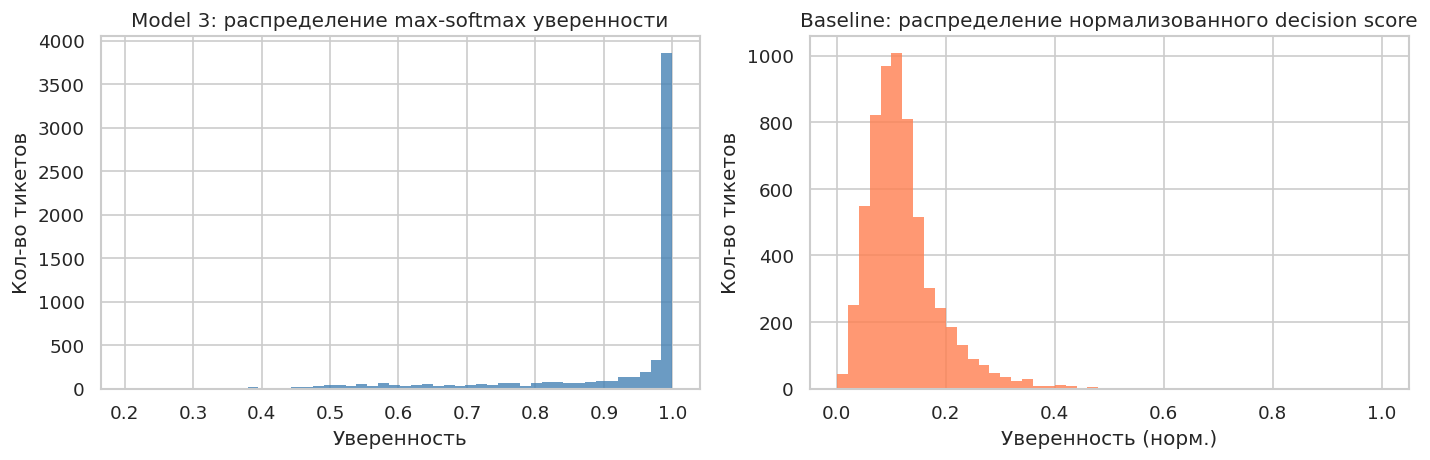

In [147]:
# Распределение уверенности
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(conf_q, bins=50, color="steelblue", edgecolor="none", alpha=0.8)
axes[0].set_title("Model 3: распределение max-softmax уверенности")
axes[0].set_xlabel("Уверенность")
axes[0].set_ylabel("Кол-во тикетов")

axes[1].hist(conf_baseline, bins=50, color="coral", edgecolor="none", alpha=0.8)
axes[1].set_title("Baseline: распределение нормализованного decision score")
axes[1].set_xlabel("Уверенность (норм.)")
axes[1].set_ylabel("Кол-во тикетов")

plt.tight_layout()
plt.show()

Распределения принципиально разные:

- Model 3

огромный пик у 1, в него входят хвостовые классы с уникальным словарём. Оставшиеся тикеты +- равномерно распределены по отрезку [0.4, 0.95]

- Baseline

колоколообразное распределение вокруг 0.1–0.15. LinearSVC не умеет быть "очень уверенным" - decision scores сжаты в узкий диапазон. Это объясняет плоскую кривую на первом графике, baseline не может надёжно отделить лёгкие случаи от сложных

# Итог

In [151]:
summary = pd.DataFrame([
    {"Model": "TF-IDF + LinearSVC",  "queue_mF1": round(baseline_results["queue_macro_f1"],4), "priority_acc": round(baseline_results["priority_acc"],4), "type_acc": round(baseline_results["type_acc"],4), "SCORE": round(score_baseline,4)},
    {"Model": "Model 1 (4 epochs)",  "queue_mF1": round(test_res["queue_macro_f1"],4),          "priority_acc": round(test_res["priority_acc"],4),          "type_acc": round(test_res["type_acc"],4),          "SCORE": round(score_1,4)},
    {"Model": "Model 2 (6 epochs)",  "queue_mF1": round(test_res_2["queue_macro_f1"],4),        "priority_acc": round(test_res_2["priority_acc"],4),        "type_acc": round(test_res_2["type_acc"],4),        "SCORE": round(score_2,4)},
    {"Model": "Model 3 (12 epochs)", "queue_mF1": round(test_res_3["queue_macro_f1"],4),        "priority_acc": round(test_res_3["priority_acc"],4),        "type_acc": round(test_res_3["type_acc"],4),        "SCORE": round(score_3,4)},
    {"Model": "KNN (cosine, K=1)",   "queue_mF1": round(knn_results["queue_macro_f1"],4),       "priority_acc": round(knn_results["priority_acc"],4),       "type_acc": round(knn_results["type_acc"],4),       "SCORE": round(score_knn,4)},
])
summary.style.background_gradient(subset=["SCORE"]).hide(axis="index")

Model,queue_mF1,priority_acc,type_acc,SCORE
TF-IDF + LinearSVC,0.883200,0.697900,0.894300,0.857100
Model 1 (4 epochs),0.857900,0.512100,0.844600,0.804000
Model 2 (6 epochs),0.895400,0.546400,0.861100,0.837900
Model 3 (12 epochs),0.923700,0.740800,0.896100,0.892100
"KNN (cosine, K=1)",0.928600,0.775900,0.909000,0.902800
